In [2]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import nibabel as nib
import pydicom
import pandas as pd

print("Everything imported successfully!")


Everything imported successfully!


In [5]:
import sys
print (sys.executable)


/opt/anaconda3/bin/python


In [7]:
import sys
!{sys.executable} -m pip install SimpleITK nibabel pydicom pandas matplotlib numpy


  Using cached simpleitk-2.5.5-cp311-abi3-macosx_11_0_arm64.whl.metadata (7.2 kB)
  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached pydicom-3.0.2-py3-none-any.whl.metadata (9.4 kB)
Using cached simpleitk-2.5.5-cp311-abi3-macosx_11_0_arm64.whl (38.6 MB)
Using cached nibabel-5.4.2-py3-none-any.whl (3.3 MB)
Using cached pydicom-3.0.2-py3-none-any.whl (2.4 MB)


In [4]:
from pathlib import Path
import SimpleITK as sitk

# CT folder path
ct_path = Path(
    "data/raw/manifest-1779461155262/QIN-BREAST/QIN-BREAST-01-0001/09-01-1991-NA-BREAST PRONE-21963/2.000000-CTAC-02377"
)

# PET folder path
pet_path = Path(
    "data/raw/manifest-1779461155262/QIN-BREAST/QIN-BREAST-01-0001/09-01-1991-NA-BREAST PRONE-21963/3.000000-PET AC 3DWB-32672"
)

print("CT path exists:", ct_path.exists())
print("PET path exists:", pet_path.exists())


CT path exists: True
PET path exists: True


In [6]:
# Read CT DICOM series
ct_reader = sitk.ImageSeriesReader()

ct_dicom_names = ct_reader.GetGDCMSeriesFileNames(str(ct_path))
ct_reader.SetFileNames(ct_dicom_names)

ct_image = ct_reader.Execute()

print("CT image loaded successfully!")


CT image loaded successfully!


In [8]:
print("CT Size:", ct_image.GetSize())
print("CT Spacing:", ct_image.GetSpacing())
print("CT Origin:", ct_image.GetOrigin())
print("CT Direction:", ct_image.GetDirection())


CT Size: (512, 512, 83)
CT Spacing: (1.367188, 1.367188, 3.27)
CT Origin: (350.0, 350.0, -300.64)
CT Direction: (-1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


In [10]:
# Read PET DICOM series
pet_reader = sitk.ImageSeriesReader()

pet_dicom_names = pet_reader.GetGDCMSeriesFileNames(str(pet_path))
pet_reader.SetFileNames(pet_dicom_names)

pet_image = pet_reader.Execute()

print("PET image loaded successfully!")


PET image loaded successfully!


ImageSeriesReader (0x10ce133d0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.019741



In [12]:
print("PET Size:", pet_image.GetSize())
print("PET Spacing:", pet_image.GetSpacing())
print("PET Origin:", pet_image.GetOrigin())
print("PET Direction:", pet_image.GetDirection())


PET Size: (128, 128, 83)
PET Spacing: (5.46875, 5.46875, 3.269756224097207)
PET Origin: (347.265625, 347.265625, -300.60000610351)
PET Direction: (-1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


In [14]:
import matplotlib.pyplot as plt
import SimpleITK as sitk

ct_array = sitk.GetArrayFromImage(ct_image)
pet_array = sitk.GetArrayFromImage(pet_image)

print("CT array shape:", ct_array.shape)
print("PET array shape:", pet_array.shape)

CT array shape: (83, 512, 512)
PET array shape: (83, 128, 128)


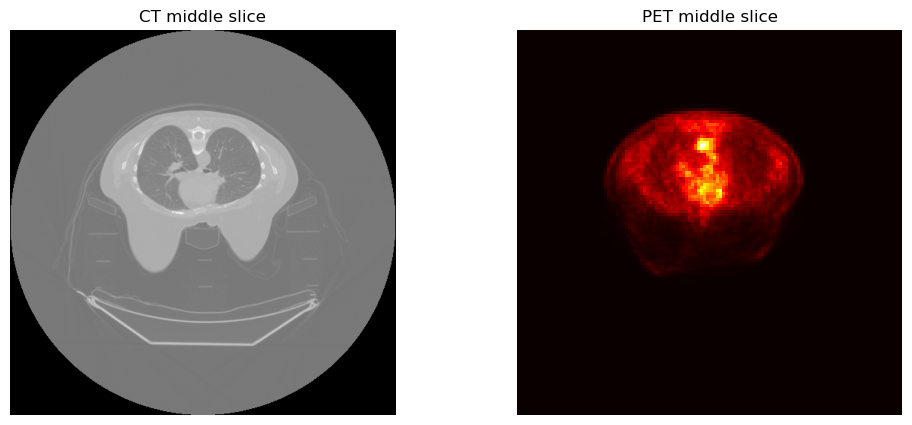

In [16]:
slice_index = ct_array.shape[0] // 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.title("CT middle slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pet_array[slice_index], cmap="hot")
plt.title("PET middle slice")
plt.axis("off")

plt.show()